# GenCP VHR Deblurring demo (For Google Colab)

* This notebook demonstrates the image deblurring performance of the LaKDNet model on high-resolution synthetic blurry images, along with the resulting outputs.

* The `gencp_VHR_deblurring_data_test` directory contains the following:

- **input**: Synthetic images generated by running **GenCP_demo_VHR_for_colab.ipynb**  
- **masks**: The corresponding masks of the images  
- **target**: The original (ground-truth) images

* The LaKDNet model can be accessed at the following link:  
[https://github.com/lingyanruan/LaKDNet](https://github.com/lingyanruan/LaKDNet)  

    Note: The repository indicates that the implementation uses PyTorch.

* The deblured images are saved in the directory **"./output_lakdnet/"**.
* The model weights were produced by fine-tuning on the VHR dataset for 20 epochs.  
The link to the weights is provided below:  
[Model Weights Link for deblurring](https://mega.nz/file/XLBnAbwK#oB6VTNxJa506adn9GK8NQg3sfWvG7lIjqXt8PW-MuNk)



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Installation

In [ ]:
!pip install -r "/content/drive/MyDrive/AI4QC/GenCP_VHR_deblurring_demo/requirements.txt" # if the file is compatible with Python 3.12 and the latest Colab, using it is unnecessary.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.8 MB/s eta 0:00:00


In [ ]:
!pip install gdal==3.6.4

In [ ]:
!python --version

Python 3.12.12


## Install Library

In [3]:
import os, glob
import random
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt


## Visualize OSM raster example

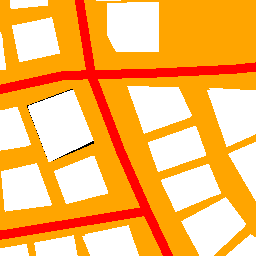

In [ ]:
# path to test set
dataroot = r"/content/drive/MyDrive/AI4QC/GenCP_VHR_deblurring_demo/gencp_VHR_deblurring_data_test/masks"

# show test data example
img_example = random.choice(os.listdir(dataroot))
SELECTED_ID = os.path.splitext(img_example)[0].split("_")[-1]
img = Image.open(os.path.join(dataroot, img_example))
display(img)



## Visualize Test Data

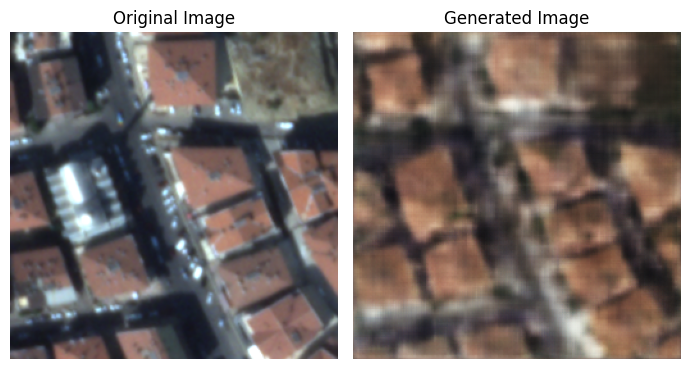

In [ ]:
# path to test set
dataroot_dblr_in = r"/content/drive/MyDrive/AI4QC/GenCP_VHR_deblurring_demo/gencp_VHR_deblurring_data_test/input" # GENCP VHR DEMO output images (generated images) path.
dataroot_dblr_tar = r"/content/drive/MyDrive/AI4QC/GenCP_VHR_deblurring_demo/gencp_VHR_deblurring_data_test/target" # GENCP VHR DEMO original images path.


exts = {".tif"}

# Create a matching key by removing _preds if it exists in input files.
def make_key(fname):
    name = os.path.splitext(os.path.basename(fname))[0]
    name = name.replace("_preds", "")
    return name

def tail_id(fname):
    name = make_key(fname)
    return name.split("_")[-1]

a = {
    make_key(p): p
    for p in glob.glob(os.path.join(dataroot_dblr_in, "*"))
    if os.path.splitext(p)[1].lower() in exts
}

b = {
    make_key(p): p
    for p in glob.glob(os.path.join(dataroot_dblr_tar, "*"))
    if os.path.splitext(p)[1].lower() in exts
}

common = sorted(a.keys() & b.keys())

if "SELECTED_ID" in globals():
    common = [k for k in common if k.split("_")[-1] == SELECTED_ID]

for key in common:
    L = Image.open(a[key]).convert("RGB")  # Generated / preds
    R = Image.open(b[key]).convert("RGB")  # Original / target

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(R)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(L)
    plt.title("Generated Image")
    plt.axis("off")

    plt.suptitle(key, fontsize=10)
    plt.tight_layout()
    plt.show()


## Deblur images for all test samples

In [ ]:
!python /content/drive/MyDrive/AI4QC/GenCP_VHR_deblurring_demo/test_Deblurring.py \
  --model_path "/content/drive/MyDrive/AI4QC/GenCP_VHR_deblurring_demo/Deblurring_model_weight/train_on_realr_s_epoch20_fine_tune_for_v1.pth" \
  --input_files "/content/drive/MyDrive/AI4QC/GenCP_VHR_deblurring_demo/gencp_VHR_deblurring_data_test/input/*.tif" \
  --target_files  "/content/drive/MyDrive/AI4QC/GenCP_VHR_deblurring_demo/gencp_VHR_deblurring_data_test/target/*.tif" \
  --output_folder "/content/drive/MyDrive/AI4QC/GenCP_VHR_deblurring_demo/output_lakdnet" \
  --config_yaml "/content/drive/MyDrive/AI4QC/GenCP_VHR_deblurring_demo/options/fine_tuning_config_test.yaml" \
  --type Motion

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100% 233M/233M [00:01<00:00, 193MB/s]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Model: /content/drive/MyDrive/AI4QC/VHR_De

## Visualize generated images

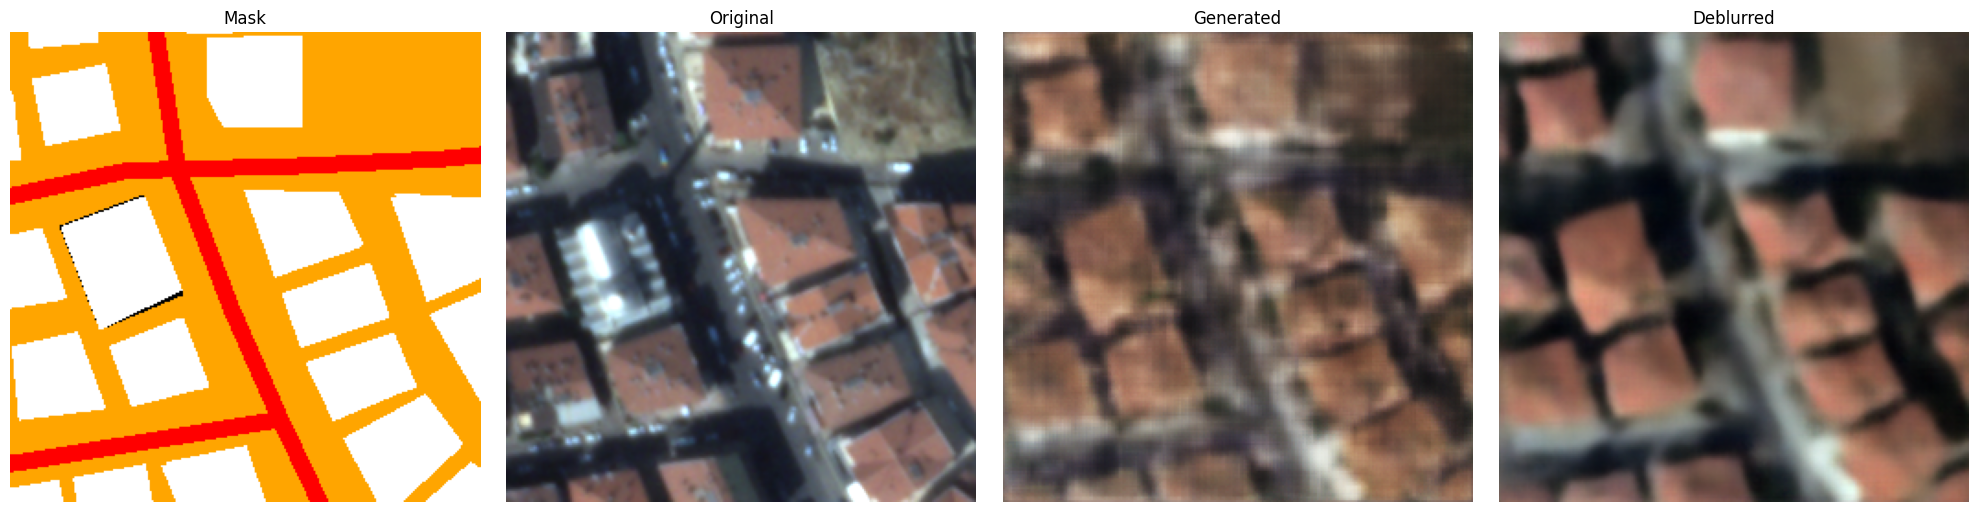

In [ ]:
generated_dataroot = r"/content/drive/MyDrive/AI4QC/GenCP_VHR_deblurring_demo/output_lakdnet"

# file extensions
exts = {".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp"}

m = {os.path.basename(p): p
     for p in glob.glob(os.path.join(dataroot, "*"))
     if os.path.splitext(p)[1].lower() in exts}

g = {os.path.basename(p): p
     for p in glob.glob(os.path.join(generated_dataroot, "**", "*"), recursive=True)
     if os.path.splitext(p)[1].lower() in exts}

def tail_id_from_name(name):
    base = os.path.splitext(name)[0]
    parts = base.split("_")

    # remove suffixes
    while parts[-1].lower() in ["deblurred", "preds", "output", "generated"]:
        parts = parts[:-1]

    return parts[-1]

def find_by_id(dct, the_id):
    for k in dct.keys():
        if tail_id_from_name(k) == the_id:
            return k
    return None


for name in common:
    _id = tail_id_from_name(name)          # input/target ID
    gen_name  = find_by_id(g, _id)
    mask_name = find_by_id(m, _id)

    # Uploads
    im_in  = Image.open(a[name]).convert("RGB")             # input
    im_tar = Image.open(b[name]).convert("RGB")             # target (GT)
    im_gen = Image.open(g[gen_name]).convert("RGB") if gen_name else None
    im_msk = Image.open(m[mask_name]) if mask_name else None

    # Plot
    plt.figure(figsize=(20, 5))

    # 1) MASK
    ax = plt.subplot(1, 4, 1)
    if im_msk is not None:
        if im_msk.mode in ("L", "I", "I;16"):
            plt.imshow(im_msk, cmap="gray")
        else:
            plt.imshow(im_msk)
    else:
        plt.text(0.5, 0.5, "Mask not found", ha="center", va="center")
    ax.set_title("Mask"); ax.axis("off")

    # 3) Generated
    ax = plt.subplot(1, 4, 3)
    plt.imshow(im_in); ax.set_title("Generated"); ax.axis("off")

    # 2) Original (GT)
    ax = plt.subplot(1, 4, 2)
    plt.imshow(im_tar); ax.set_title("Original"); ax.axis("off")

    # 4) GENERATED (Deblurred)
    ax = plt.subplot(1, 4, 4)
    if im_gen is not None:
        plt.imshow(im_gen)
    else:
        plt.text(0.5, 0.5, "Generated not found", ha="center", va="center")
    ax.set_title("Deblurred"); ax.axis("off")

    plt.tight_layout()
    plt.show()

